<a href="https://colab.research.google.com/github/imdann06/estructra_de_bases_de_datos/blob/main/QuadTree/QuadTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problema

Problema
Eres parte de un equipo que desarrolla un sistema de logistica de entregas en una ciudad.
Tienes coordenadas (x,y) de 10.000 puntos de entrega (estos datos los puedes tomar de datos reales
o generarlos, para este ejercicio los datos son estaticos, es decir, no cambian).

Necesitas implementar un sistema que responda eficientemente preguntas como:
* ¿que puntos de entrega estan a un radio de 500 metros de un punto dado? (tener en cuenta unidades)
* ¿cual es el puntos de entrega mas cercano a una ubicacion dada?

Objetivo: Implementar un Arbol-Quadtree desde cero, y comparar con fuerza bruta.

Micro-tareas para resolver el ejercicio:
* Construir el arbol Quadtree (no se pueden usar arboles ya generados o librerias como scipy)
* Implementar busqueda dentro de un radio (Range Search)
* Vecinos (puntos encontrados dentro del radio) y encontrar los mas cercanos
* Verificacion visual de radio y puntos encontrados dentro del radio.
* Verificacion visual de los vecinos mas cercanos.
Notas:
* IMPORTANTE: trate de hacer el codigo para K-dimensiones, sino, puede ser solo para 2D
* No se permiten soluciones completas de internet o vibe coding, sí se pueden apoyar de IA o internet
* Se puede hacer preguntas

Responder las siguientes preguntas en el analisis comparativo:
* para que tamaño de datos el arbol-Quadtree comienza a ser mas rapido que "fuerza bruta"
(no arboles, si listas, ...)?

Forma de entrega. Repositorio github con la siguiente estructura:
README.md
Quadtreetree.py
test.py (pruebas unitarias, visualizaciones y analisis de pruebas realizadas)
analisis.py (metricas de rendimiento y discusion de resultados)


In [1]:
import random
import math
import time

class Nodo:
    def __init__(self, puntos, xmin, xmax, ymin, ymax):
        self.puntos = puntos
        self.xmin = xmin
        self.xmax = xmax
        self.ymin = ymin
        self.ymax = ymax

        self.mitad_x = (xmin + xmax) / 2
        self.mitad_y = (ymin + ymax) / 2

        self.arriba_izquierda = None
        self.arriba_derecha = None
        self.abajo_izquierda = None
        self.abajo_derecha = None


class QuadTree:
    def __init__(self, puntos, xmin, xmax, ymin, ymax):
        self.raiz = self.construir(puntos, xmin, xmax, ymin, ymax)

    def construir(self, puntos, xmin, xmax, ymin, ymax):
        # Caso base: si hay 0 o 1 punto, ya no se divide más
        if len(puntos) <= 1 or (xmax - xmin) < 1 or (ymax - ymin) < 1:
            return Nodo(puntos, xmin, xmax, ymin, ymax)

        nodo_actual = Nodo([], xmin, xmax, ymin, ymax)

        mitad_x = nodo_actual.mitad_x
        mitad_y = nodo_actual.mitad_y

        puntos_arriba_izquierda = []
        puntos_arriba_derecha = []
        puntos_abajo_izquierda = []
        puntos_abajo_derecha = []

        # Clasificar puntos en uno de los 4 cuadrantes
        for punto in puntos:
            x, y = punto

            if x <= mitad_x and y >= mitad_y:
                puntos_arriba_izquierda.append(punto)
            elif x > mitad_x and y >= mitad_y:
                puntos_arriba_derecha.append(punto)
            elif x <= mitad_x and y < mitad_y:
                puntos_abajo_izquierda.append(punto)
            else:
                puntos_abajo_derecha.append(punto)

        # Construcción recursiva de hijos
        if puntos_arriba_izquierda:
            nodo_actual.arriba_izquierda = self.construir(
                puntos_arriba_izquierda, xmin, mitad_x, mitad_y, ymax
            )

        if puntos_arriba_derecha:
            nodo_actual.arriba_derecha = self.construir(
                puntos_arriba_derecha, mitad_x, xmax, mitad_y, ymax
            )

        if puntos_abajo_izquierda:
            nodo_actual.abajo_izquierda = self.construir(
                puntos_abajo_izquierda, xmin, mitad_x, ymin, mitad_y
            )

        if puntos_abajo_derecha:
            nodo_actual.abajo_derecha = self.construir(
                puntos_abajo_derecha, mitad_x, xmax, ymin, mitad_y
            )

        return nodo_actual

    def distancia_punto_a_rectangulo(self, px, py, nodo):
        dx = max(0, nodo.xmin - px, px - nodo.xmax)
        dy = max(0, nodo.ymin - py, py - nodo.ymax)
        return math.sqrt(dx * dx + dy * dy)

    def buscar_radio(self, nodo_actual, punto_objetivo, radio):
        if nodo_actual is None:
            return []

        x, y = punto_objetivo

        # Poda: si el rectángulo del nodo está más lejos que el radio, se descarta
        if self.distancia_punto_a_rectangulo(x, y, nodo_actual) > radio:
            return []

        encontrados = []

        # Solo las hojas tienen puntos
        for punto in nodo_actual.puntos:
            px, py = punto
            distancia = math.sqrt((px - x) ** 2 + (py - y) ** 2)
            if distancia <= radio:
                encontrados.append(punto)

        encontrados.extend(
            self.buscar_radio(nodo_actual.arriba_izquierda, punto_objetivo, radio)
        )
        encontrados.extend(
            self.buscar_radio(nodo_actual.arriba_derecha, punto_objetivo, radio)
        )
        encontrados.extend(
            self.buscar_radio(nodo_actual.abajo_izquierda, punto_objetivo, radio)
        )
        encontrados.extend(
            self.buscar_radio(nodo_actual.abajo_derecha, punto_objetivo, radio)
        )

        return encontrados


# ----------------------------
# GENERAR 10.000 PUNTOS
# ----------------------------


LADO = 10000  # 10 km x 10 km

puntos = [
    (random.randint(0, LADO), random.randint(0, LADO))
    for _ in range(10000)
]

# ----------------------------
# CONSTRUIR EL QUADTREE
# ----------------------------

arbol = QuadTree(puntos, 0, LADO, 0, LADO)

# ----------------------------
# HACER UNA CONSULTA DE EJEMPLO
# ----------------------------

punto_consulta = (
    random.randint(0, LADO),
    random.randint(0, LADO)
)

radio = 500  # metros

print("Punto de consulta:", punto_consulta)
print("Radio:", radio)

vecinos = arbol.buscar_radio(arbol.raiz, punto_consulta, radio)
# Encuentra el vecino más cercano dentro de los resultados obtenidos (si hay alguno)
if vecinos:
    mas_cercano = min(
        vecinos,
        key=lambda p: (p[0] - punto_consulta[0])**2 + (p[1] - punto_consulta[1])**2
    )
    print("Vecino más cercano dentro del radio:", mas_cercano)
print("Cantidad de puntos dentro de 500 metros:", len(vecinos))
# Imprime los puntos encontrados dentro del radio
for punto in vecinos:
    print(punto)


Punto de consulta: (7988, 6174)
Radio: 500
Vecino más cercano dentro del radio: (7985, 6217)
Cantidad de puntos dentro de 500 metros: 70
(7497, 6183)
(7957, 6638)
(7904, 6593)
(8103, 6619)
(8103, 6585)
(7662, 6516)
(7739, 6536)
(7774, 6500)
(7770, 6410)
(7531, 6336)
(7545, 6267)
(7676, 6254)
(7849, 6409)
(7883, 6411)
(7998, 6495)
(7861, 6367)
(7933, 6382)
(7938, 6376)
(7880, 6275)
(7925, 6322)
(8078, 6340)
(8004, 6328)
(8117, 6255)
(8131, 6561)
(8217, 6448)
(8266, 6477)
(8208, 6436)
(8297, 6506)
(8296, 6468)
(8391, 6436)
(8173, 6400)
(8260, 6346)
(8223, 6252)
(8339, 6326)
(8355, 6325)
(8347, 6272)
(8462, 6304)
(7526, 6202)
(7543, 6206)
(7667, 6197)
(7706, 6149)
(7710, 6097)
(7753, 6135)
(7505, 6074)
(7623, 5973)
(7985, 6217)
(8089, 6153)
(7697, 5817)
(7812, 5758)
(7828, 5867)
(7990, 5887)
(8004, 5847)
(7904, 5696)
(8215, 6198)
(8231, 6138)
(8312, 6237)
(8329, 6226)
(8419, 6142)
(8215, 6030)
(8397, 6020)
(8418, 5958)
(8472, 6167)
(8161, 5828)
(8214, 5807)
(8285, 5928)
(8339, 5883)
(8316

In [2]:
import time

# ----------------------------
# FUERZA BRUTA
# ----------------------------
def fuerza_bruta_radio(puntos, punto_consulta, radio):
    x, y = punto_consulta
    encontrados = []

    for px, py in puntos:
        distancia = math.sqrt((px - x) ** 2 + (py - y) ** 2)
        if distancia <= radio:
            encontrados.append((px, py))

    return encontrados


# ----------------------------
# MEDIR TIEMPOS PROMEDIO
# ----------------------------
NUM_PRUEBAS = 1000

tiempo_total_qt = 0
tiempo_total_fb = 0

for i in range(NUM_PRUEBAS):

    # Quadtree
    inicio = time.time()
    arbol.buscar_radio(arbol.raiz, punto_consulta, radio)
    tiempo_total_qt += time.time() - inicio

    # Fuerza bruta
    inicio = time.time()
    fuerza_bruta_radio(puntos, punto_consulta, radio)
    tiempo_total_fb += time.time() - inicio

# Calcular promedios
promedio_qt = tiempo_total_qt / NUM_PRUEBAS
promedio_fb = tiempo_total_fb / NUM_PRUEBAS

print("TIEMPOS PROMEDIO")
print(f"QuadTree: {promedio_qt:.6f} segundos")
print(f"Fuerza bruta: {promedio_fb:.6f} segundos")

TIEMPOS PROMEDIO
QuadTree: 0.000733 segundos
Fuerza bruta: 0.006918 segundos


In [3]:
def experimento_comparativo(tamanos, num_consultas=20, lado=20000, radio=500, repeticiones_por_consulta=1000):
    print("\n==============================")
    print("EXPERIMENTO QUADTREE VS FUERZA BRUTA")
    print("==============================")

    tabla = []

    for n in tamanos:
        puntos = [
            (random.randint(0, lado), random.randint(0, lado))
            for i in range(n)
        ]

        inicio_construccion = time.time()
        arbol = QuadTree(puntos, 0, lado, 0, lado)
        tiempo_construccion = time.time() - inicio_construccion

        tiempo_total_qt = 0
        tiempo_total_fb = 0
        coincidencias = True

        for i in range(num_consultas):
            punto_consulta = (
                random.randint(0, lado),
                random.randint(0, lado)
            )

            # Verificación de correctitud una sola vez por consulta
            resultado_qt = arbol.buscar_radio(arbol.raiz, punto_consulta, radio)
            resultado_fb = fuerza_bruta_radio(puntos, punto_consulta, radio)

            if set(resultado_qt) != set(resultado_fb):
                coincidencias = False

            # Medir QuadTree muchas veces
            inicio_qt = time.time()
            for _ in range(repeticiones_por_consulta):
                arbol.buscar_radio(arbol.raiz, punto_consulta, radio)
            tiempo_total_qt += (time.time() - inicio_qt) / repeticiones_por_consulta

            # Medir fuerza bruta muchas veces
            inicio_fb = time.time()
            for _ in range(repeticiones_por_consulta):
                fuerza_bruta_radio(puntos, punto_consulta, radio)
            tiempo_total_fb += (time.time() - inicio_fb) / repeticiones_por_consulta

        promedio_qt = tiempo_total_qt / num_consultas
        promedio_fb = tiempo_total_fb / num_consultas

        tabla.append({
            "n": n,
            "tiempo_construccion": tiempo_construccion,
            "promedio_qt": promedio_qt,
            "promedio_fb": promedio_fb,
            "coincidencias": coincidencias
        })

        print(f"\nTamaño de datos: {n}")
        print(f"Tiempo construcción QuadTree: {tiempo_construccion:.6f} s")
        print(f"Tiempo promedio consulta QuadTree: {promedio_qt:.8f} s")
        print(f"Tiempo promedio fuerza bruta: {promedio_fb:.8f} s")
        print(f"¿Resultados iguales en todas las consultas?: {coincidencias}")

        if promedio_qt < promedio_fb:
            print("QuadTree fue más rápido en promedio")
        elif promedio_fb < promedio_qt:
            print("Fuerza bruta fue más rápida en promedio")
        else:
            print("Empate")

    return tabla

In [4]:
# Define una lista de tamaños de datos para probar en el experimento
tamanos = [ 10,20,40, 50, 60, 80, 100, 200]
# Ejecuta el experimento comparativo con los tamaños definidos


tabla_resultados = experimento_comparativo(
    tamanos,
    num_consultas=20,
    lado=20000,
    radio=500,
    repeticiones_por_consulta=1000
)


EXPERIMENTO QUADTREE VS FUERZA BRUTA

Tamaño de datos: 10
Tiempo construcción QuadTree: 0.000046 s
Tiempo promedio consulta QuadTree: 0.00001236 s
Tiempo promedio fuerza bruta: 0.00000549 s
¿Resultados iguales en todas las consultas?: True
Fuerza bruta fue más rápida en promedio

Tamaño de datos: 20
Tiempo construcción QuadTree: 0.000089 s
Tiempo promedio consulta QuadTree: 0.00001794 s
Tiempo promedio fuerza bruta: 0.00001117 s
¿Resultados iguales en todas las consultas?: True
Fuerza bruta fue más rápida en promedio

Tamaño de datos: 40
Tiempo construcción QuadTree: 0.000199 s
Tiempo promedio consulta QuadTree: 0.00002269 s
Tiempo promedio fuerza bruta: 0.00002050 s
¿Resultados iguales en todas las consultas?: True
Fuerza bruta fue más rápida en promedio

Tamaño de datos: 50
Tiempo construcción QuadTree: 0.000222 s
Tiempo promedio consulta QuadTree: 0.00001624 s
Tiempo promedio fuerza bruta: 0.00001749 s
¿Resultados iguales en todas las consultas?: True
QuadTree fue más rápido en pro

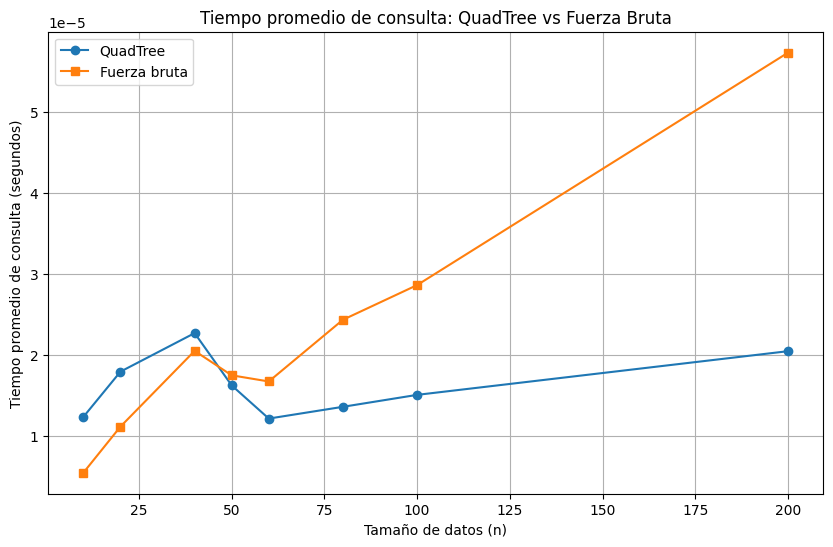

In [5]:
import matplotlib.pyplot as plt

n_valores = [fila["n"] for fila in tabla_resultados]
tiempos_qt = [fila["promedio_qt"] for fila in tabla_resultados]
tiempos_fb = [fila["promedio_fb"] for fila in tabla_resultados]

plt.figure(figsize=(10, 6))
plt.plot(n_valores, tiempos_qt, marker="o", label="QuadTree")
plt.plot(n_valores, tiempos_fb, marker="s", label="Fuerza bruta")

plt.title("Tiempo promedio de consulta: QuadTree vs Fuerza Bruta")
plt.xlabel("Tamaño de datos (n)")
plt.ylabel("Tiempo promedio de consulta (segundos)")
plt.legend()
plt.grid(True)
plt.show()

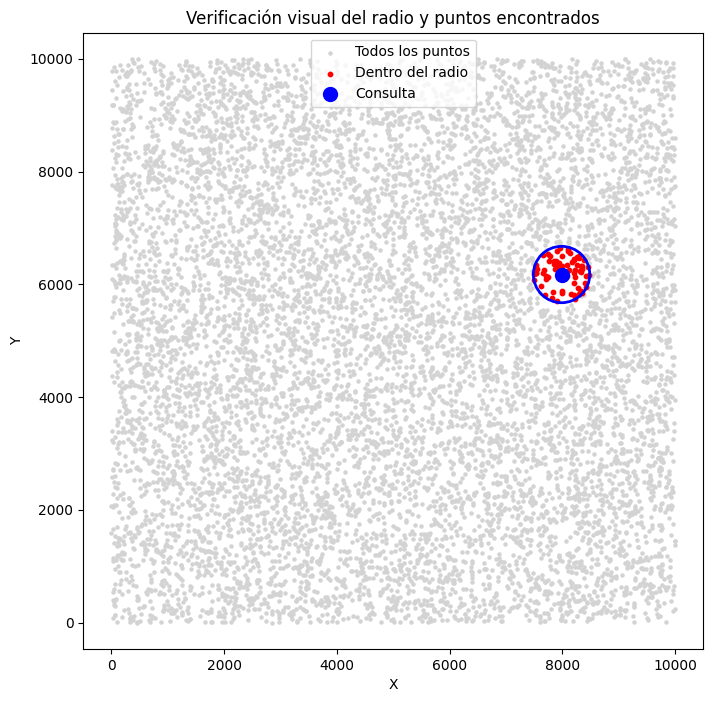

In [6]:
import matplotlib.pyplot as plt

# ----------------------------
# VISUALIZACIÓN DE TODOS LOS PUNTOS Y EL RADIO DE CONSULTA
# ----------------------------

# Coordenadas de todos los puntos
x_all = [p[0] for p in puntos]
y_all = [p[1] for p in puntos]

# Coordenadas de los puntos encontrados dentro del radio
x_vecinos = [p[0] for p in vecinos]
y_vecinos = [p[1] for p in vecinos]

plt.figure(figsize=(8, 8))

# Todos los puntos
plt.scatter(x_all, y_all, s=5, color='lightgray', label="Todos los puntos")

# Puntos dentro del radio
plt.scatter(x_vecinos, y_vecinos, s=10, color='red', label="Dentro del radio")

# Punto de consulta
plt.scatter(punto_consulta[0], punto_consulta[1], color='blue', s=100, label="Consulta")

# Círculo del radio
circulo = plt.Circle(punto_consulta, radio, color='blue', fill=False, linewidth=2)
plt.gca().add_patch(circulo)

plt.title("Verificación visual del radio y puntos encontrados")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.axis('equal')
plt.show()

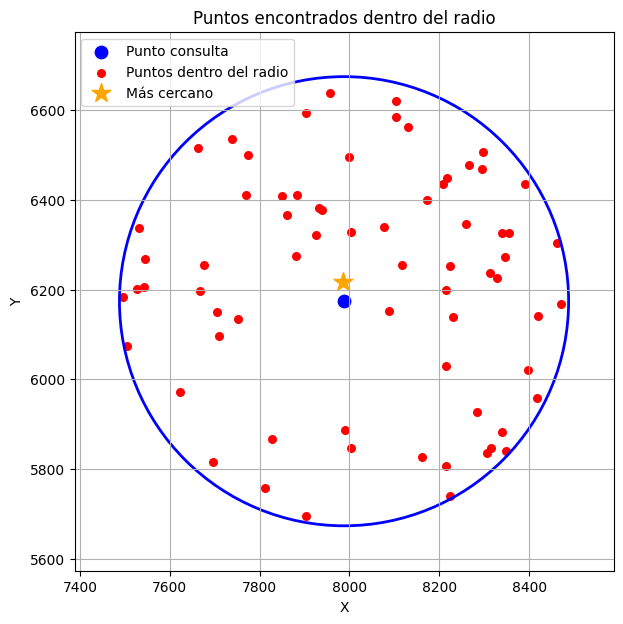

In [7]:
import matplotlib.pyplot as plt

# ----------------------------
# VISUALIZACIÓN SOLO DEL RADIO (Detalle)
# ----------------------------

# Separa las coordenadas X e Y de los puntos encontrados dentro del radio
x_vecinos = [p[0] for p in vecinos]
y_vecinos = [p[1] for p in vecinos]

# Crea una nueva figura para el gráfico de detalle
plt.figure(figsize=(7, 7))

# Dibuja el punto de consulta en azul
plt.scatter(punto_consulta[0], punto_consulta[1], s=80, color="blue", label="Punto consulta")

# Dibuja los puntos encontrados dentro del radio en rojo
plt.scatter(x_vecinos, y_vecinos, s=30, color="red", label="Puntos dentro del radio")

# Dibuja el vecino más cercano si existe
if vecinos:
    plt.scatter(mas_cercano[0], mas_cercano[1],
                color='orange', s=200, marker='*', label="Más cercano")

# Dibuja el círculo que representa el radio de búsqueda
circulo = plt.Circle(punto_consulta, radio, fill=False, color="blue", linewidth=2)
plt.gca().add_patch(circulo)

# Configura los límites de los ejes para mostrar solo la zona del círculo con un margen
margen = 100
plt.xlim(punto_consulta[0] - radio - margen, punto_consulta[0] + radio + margen)
plt.ylim(punto_consulta[1] - radio - margen, punto_consulta[1] + radio + margen)

# Asegura que la relación de aspecto sea igual para un círculo correcto
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Puntos encontrados dentro del radio")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()